# Companion code for the paper "A General Framework for Block-Sparse Recovery Conditions via Weighted Mixed and Operator Norms"


**Authors:** Fardin Afdideh, Ronald Phlypo, Christian Jutten

This companion notebook contains the Python code to reproduce the numerical experiments (Figures 2 and 3) presented in the manuscript. It computes the attainable sparsity levels (SL) which govern the recovery guarantees and thresholds.


Experiments:
* Experiment 1 (Fig. 2): SL sensitivity to dictionary type, block length, operator norm
* Experiment II (Fig. 3): SL vs. sub-coherence



## Experiment 1 (Fig. 2): SL sensitivity to dictionary type, block length, operator norm

> *"SL as a function of block length $d$ for different values of $q$ and $p$, averaged over `rpt=100` realisations of random dictionaries, with $m=40$ and $n=400$."*

For every block length $d \in \{1,2,4,5,8,10\}$ (the first 6 divisors of $n=400$), a random dictionary $\mathbf{\Phi}\in\mathbb{R}^{40\times400}$ is generated (`phi_generator`), together with an intra-block-orthonormalised version $\mathbf{\Phi}_{ort}$. For both dictionaries we compute the **Block Mutual Coherence Constant (BMCC)** (`bmcc.m`) for:

* the 6 proposed operator norms $M_{q,p}(\mathbf{\Phi})$, $(q,p)\in\{(1,1),(1,2),(1,\infty),(2,2),(2,\infty),(\infty,\infty)\}$ (Property III.1 of the manuscript),
* [11]'s block coherence $\mu_B$ and sub-coherence $\nu$ [Y. Eldar, P. Kuppinger, and H. B¨olcskei, “Block-sparse signals: Uncertainty relations and efficient recovery,” IEEE Trans. Signal Process., vol. 58, no. 6, pp. 3042–3054, 2010],
* [16]'s conventional mutual coherence [D. Donoho and M. Elad, “Optimally sparse representation in general (nonorthogonal) dictionaries via ℓ1 minimization,” in Proc. Natl. Acad. Sci., vol. 100, no. 5, pp. 2197–2202, 2003].

From these coherence constants we compute the corresponding attainable **sparsity levels (SL)** average them over the repetitions, and reproduce the grouped bar chart of Fig. 2.

The heavy nested loops (`for` over blocks $k,k'$) are implemented by fully vectorised NumPy batch operations, so the whole simulation with `rpt=100` runs in a few minutes on a standard Colab CPU runtime (vs. a much longer runtime for a literal, non-vectorised translation).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

np.set_printoptions(precision=4, suppress=True)

### 1. Utility functions

* **`bmcc_coeff`** — the closed-form coefficient in front of the $\ell_{q\to p}$ operator norm in Property III.1, for the 6 tractable pairs `qpCounter ∈ {1,...,6} = {(1,1),(1,2),(1,\infty),(2,2),(2,\infty),(\infty,\infty)}`.
* **`phi_generator`** — draws a random Gaussian dictionary, normalises columns to unit $\ell_2$-norm (`\Phi`), and builds an intra-block-orthonormal companion `\Phi_ort` by replacing every block of columns with an orthonormal basis of the same column space.
* **`bmcc`** — for a given dictionary and block length $d$, computes the 9 coherence constants used in Fig. 2: the 6 proposed $M_{q,p}(\mathbf{\Phi})$ (Property III.1), [11]'s $\mu_B$ and sub-coherence $\nu$, and the conventional mutual coherence [16].
It is fully vectorised: instead of looping in Python over every ordered pair of blocks $(k,k')$, all block pseudo-inverses and all pairwise cross-block products are formed as single batched array operations (batched `pinv`, batched matrix multiplication, batched SVD for the spectral-norm cases), and the maximisation over blocks is a NumPy reduction.

In [2]:
def bmcc_coeff(r_1, r_2, r_max, qp_counter):
    """Coefficient of the (q,p) operator norm in the BMCC formula (Property III.1).

    qp_counter: 1:(1,1)  2:(1,2)  3:(1,inf)  4:(2,2)  5:(2,inf)  6:(inf,inf)
    """
    if qp_counter == 1:
        return r_2 / (r_max * r_1)
    elif qp_counter == 2:
        return r_2 / (r_max * np.sqrt(r_1))
    elif qp_counter == 3:
        return r_2 / r_max
    elif qp_counter == 4:
        return np.sqrt(r_2) / (r_max * np.sqrt(r_1))
    elif qp_counter == 5:
        return np.sqrt(r_2) / r_max
    elif qp_counter == 6:
        return 1.0 / r_max
    raise ValueError("qp_counter must be in {1,...,6}")


def phi_generator(phi_ini, blocks_nb, rng):
    """Build (Phi, Phi_ort) from an initial Gaussian dictionary `phi_ini`.

    phi_ini   : (m, n) initial i.i.d. Gaussian dictionary
    blocks_nb : number of equally-sized blocks (n must be divisible by blocks_nb)
    rng       : numpy.random.Generator

    Returns
    -------
    A      : (m, n) dictionary with unit-norm columns ("regular" dictionary)
    A_ort  : (m, n) dictionary with the same block structure, but each block of
             columns replaced by an orthonormal basis of its column span
             (intra-block orthonormality, A_ortho in the manuscript)
    """
    m, n = phi_ini.shape
    block_len = n // blocks_nb

    blocks_idx = np.repeat(np.arange(blocks_nb), block_len)
    weights = rng.random(blocks_nb) + 0.1
    W = 1.0 / weights[blocks_idx]
    A = phi_ini * W[np.newaxis, :]
    A = A / np.linalg.norm(A, axis=0, keepdims=True)

    # batched orthonormal basis per block == scipy.linalg.orth(A[:, block]) for every block
    blocks = A.reshape(m, blocks_nb, block_len).transpose(1, 0, 2)   # (blocks_nb, m, block_len)
    U, _, _ = np.linalg.svd(blocks, full_matrices=False)             # (blocks_nb, m, block_len)
    A_ort = U.transpose(1, 0, 2).reshape(m, n)

    return A, A_ort


def bmcc(phi, r):
    """Block Mutual Coherence Constant(s) of dictionary `phi` for block length `d`.

    Returns a length-9 array:
      [0:6] the 6 proposed M_{q,p}(Phi)   -> (1,1) (1,2) (1,inf) (2,2) (2,inf) (inf,inf)
      [6]   [11]'s mu_B
      [7]   [11]'s sub-coherence nu
      [8]   [16]'s conventional mutual coherence
    """
    m, n = phi.shape
    block_nb = n // r
    coeff = np.array([bmcc_coeff(r, r, r, k) for k in range(1, 7)])
    BMCC = np.zeros(9)

    # --- all blocks stacked: (block_nb, m, r) ---
    blocks = phi.reshape(m, block_nb, r).transpose(1, 0, 2)

    # --- Property III.1: TEMP_{k,k'} = pinv(Phi_k) @ Phi_k' for every ordered pair ---
    pinv_blocks = np.linalg.pinv(blocks)          # (block_nb, r, m), batched pseudo-inverse
    TEMP = pinv_blocks @ phi                       # (block_nb, r, n)
    TEMP4 = TEMP.reshape(block_nb, r, block_nb, r)  # axes: (k, row-in-block-k, k', col-in-block-k')
    mask = ~np.eye(block_nb, dtype=bool)            # exclude k'=k

    absT = np.abs(TEMP4)
    n11 = absT.sum(axis=1).max(axis=2)                          # (1,1) operator norm per (k,k')
    n12 = np.sqrt((TEMP4 ** 2).sum(axis=1)).max(axis=2)         # (1,2)
    n1inf = absT.max(axis=(1, 3))                                # (1,inf)
    n2inf = np.sqrt((TEMP4 ** 2).sum(axis=3)).max(axis=1)       # (2,inf)
    ninfinf = absT.sum(axis=3).max(axis=1)                       # (inf,inf)
    sv = np.linalg.svd(TEMP4.transpose(0, 2, 1, 3), compute_uv=False)  # (k,k',r) singular values
    n22 = sv.max(axis=-1)                                        # (2,2) = spectral norm

    for idx, narr in enumerate([n11, n12, n1inf, n22, n2inf, ninfinf]):
        vals = np.where(mask, coeff[idx] * narr, -np.inf)
        BMCC[idx] = vals.max()

    # --- [11]'s mu_B = (1/d) * ||Phi_k^T Phi_k'||_2, maximised over k != k' ---
    blocksT = blocks.transpose(0, 2, 1)            # (block_nb, r, m) == Phi_k^T
    C = blocksT @ phi                              # (block_nb, r, n)
    C4 = C.reshape(block_nb, r, block_nb, r)
    svC = np.linalg.svd(C4.transpose(0, 2, 1, 3), compute_uv=False)
    muB = np.where(mask, svC.max(axis=-1) / r, -np.inf)
    BMCC[6] = muB.max()

    # --- [11]'s sub-coherence nu: max |off-diagonal| of Phi_k^T Phi_k, over k ---
    if r > 1:
        G_blocks = blocksT @ blocks                 # (block_nb, r, r)
        offmask_r = ~np.eye(r, dtype=bool)
        sub_coh = np.array([np.abs(G_blocks[k])[offmask_r].max() for k in range(block_nb)])
        BMCC[7] = sub_coh.max()
    else:
        BMCC[7] = 0.0   # undefined for d=1 (no off-diagonal entries)

    # --- [16]'s coherence: max |off-diagonal| of the Gram matrix Phi^T Phi ---
    G = phi.T @ phi
    offmask_n = ~np.eye(n, dtype=bool)
    BMCC[8] = np.abs(G)[offmask_n].max()

    return BMCC

### 2. Simulation parameters

* `rpt = 100` random dictionary realisations,
* `m = 40` rows, `n = 400` columns,
* block lengths `d` = the first 6 divisors of `n`, i.e. `[1, 2, 4, 5, 8, 10]`.

A fixed `numpy` random seed is used for reproducibility of *this* notebook's run.

In [3]:
rpt = 100          # number of repetitions
m = 40             # rows in the dictionary
n = 400            # columns in the dictionary
rNb = 6            # number of different block lengths (d)
seed = 0

# [11] Y. Eldar, P. Kuppinger, and H. B¨olcskei, “Block-sparse signals: Un-
# certainty relations and efficient recovery,” IEEE Trans. Signal Process.,
# vol. 58, no. 6, pp. 3042–3054, 2010.
EldarRef ='[11]'
# [16] D. Donoho and M. Elad, “Optimally sparse representation in general
# (nonorthogonal) dictionaries via ℓ1 minimization,” in Proc. Natl. Acad.
# Sci., vol. 100, no. 5, pp. 2197–2202, 2003.
DonohoRef ='[16]'

# first rNb divisors of n
r_list = [k for k in range(1, n + 1) if n % k == 0][:rNb]
print("block lengths d:", r_list)

rng = np.random.default_rng(seed)

# BMCC[repetition, coherence-constant(9), block-length, regular(0)/orthonormal(1)]
BMCC = np.full((rpt, 9, len(r_list), 2), np.nan)

t0 = time.time()
for i in range(rpt):
    phi_ini = rng.standard_normal((m, n))
    for j, rj in enumerate(r_list):
        blocks_nb = n // rj
        A, A_ort = phi_generator(phi_ini, blocks_nb, rng)
        BMCC[i, :, j, 0] = bmcc(A, rj)
        BMCC[i, :, j, 1] = bmcc(A_ort, rj)
    if (i + 1) % 10 == 0 or i == 0:
        print(f"  {i + 1}/{rpt} repetitions done — {time.time() - t0:.1f}s elapsed")

print(f"Simulation finished in {time.time() - t0:.1f}s")

block lengths d: [1, 2, 4, 5, 8, 10]
  1/100 repetitions done — 1.9s elapsed
  10/100 repetitions done — 20.0s elapsed
  20/100 repetitions done — 40.9s elapsed
  30/100 repetitions done — 62.4s elapsed
  40/100 repetitions done — 82.3s elapsed
  50/100 repetitions done — 103.3s elapsed
  60/100 repetitions done — 123.1s elapsed
  70/100 repetitions done — 144.3s elapsed
  80/100 repetitions done — 164.1s elapsed
  90/100 repetitions done — 185.2s elapsed
  100/100 repetitions done — 205.0s elapsed
Simulation finished in 205.0s


### 3. Sparsity level (SL)

For every block length $d$ and dictionary type, we turn the coherence constants into sparsity levels:

* **Proposed SL** (Theorem III.3 / Corollary IV.2): $\displaystyle SL_{q,p}^{B} = d\left(1 + (d\, M_{q,p}(\mathbf{\Phi}))^{-1}\right)/2$ for each of the 6 $(q,p)$ pairs.
* **[11]'s SL**: $\displaystyle d\left(1 + (d\,\mu_B)^{-1} - \frac{(d-1)\nu}{d\,\mu_B}\right)/2$.
* **[16]'s SL**: $\displaystyle \left(1 + M(\mathbf{\Phi})^{-1}\right)/2$ (constant in $d$).

Negative values (which occur when a condition is not computable / not satisfiable, as discussed for [11]'s SL at $d>4$ in the manuscript) are clipped to 0.

In [4]:
nR = len(r_list)
r_arr = np.array(r_list, dtype=float)

BERC_mean = np.full((nR, 8, 2), np.nan)
BERC_std = np.full((nR, 8, 2), np.nan)

for i in range(nR):
    d = r_arr[i]
    for j in range(2):  # 0: regular dictionary, 1: intra-block orthonormal dictionary
        # Proposed SL (Theorem III.3)
        M = BMCC[:, 0:6, i, j]
        BERC = d * (1 + (d * M) ** (-1)) / 2
        BERC_mean[i, 0:6, j] = BERC.mean(axis=0)
        BERC_std[i, 0:6, j] = BERC.std(axis=0)

        # [11]'s SL
        mu_B = BMCC[:, 6, i, j]
        nu = BMCC[:, 7, i, j]
        BERC_eldar = d * (1 + (d * mu_B) ** (-1) - ((d - 1) * nu) / (d * mu_B)) / 2
        BERC_mean[i, 6, j] = BERC_eldar.mean()
        BERC_std[i, 6, j] = BERC_eldar.std()

        # [16]'s SL
        ERC = (1 + BMCC[:, 8, i, j] ** (-1)) / 2
        BERC_mean[i, 7, j] = ERC.mean()
        BERC_std[i, 7, j] = ERC.std()

# regular dictionary (Phi) and intra-block orthonormal dictionary (Phi_ort)
tmpMean = BERC_mean[:, :, 0].copy()
tmpMeanOrth = BERC_mean[:, :, 1].copy()
tmpStd = BERC_std[:, :, 0].copy()
tmpStdOrth = BERC_std[:, :, 1].copy()

tmpStd[tmpMean < 0] = 0
tmpMean[tmpMean < 0] = 0
tmpStdOrth[tmpMeanOrth < 0] = 0
tmpMeanOrth[tmpMeanOrth < 0] = 0

### 4. Fig. 2 — Sparsity level (SL) vs. dictionary type (${\Phi}$, ${\Phi}_{ort}$), block length ($d$), operator norm $(q,p)$

Grouped bar chart, one group per block length $d$. Within each group, 8 bars (dark $\to$ light gray) show the SL of $\mathbf{\Phi}$ for the 6 proposed $M_{q,p}$, [16]'s SL, and [16]'s SL; the corresponding white bars (outlined in black, drawn behind) show the same 8 SLs for the intra-block orthonormal dictionary $\mathbf{\Phi}_{ort}$. Error bars show $\pm 1$ standard deviation across the `rpt` repetitions.

<>:43: SyntaxWarning: invalid escape sequence '\P'
<>:43: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_2719/1525535363.py:43: SyntaxWarning: invalid escape sequence '\P'
  ax.set_title('Fig. 2 (reproduced) — SL as a function of dictionary type (${\Phi}$, ${\Phi}_{ort}$), block length ($d$), and operator norm $(q,p)$\n'


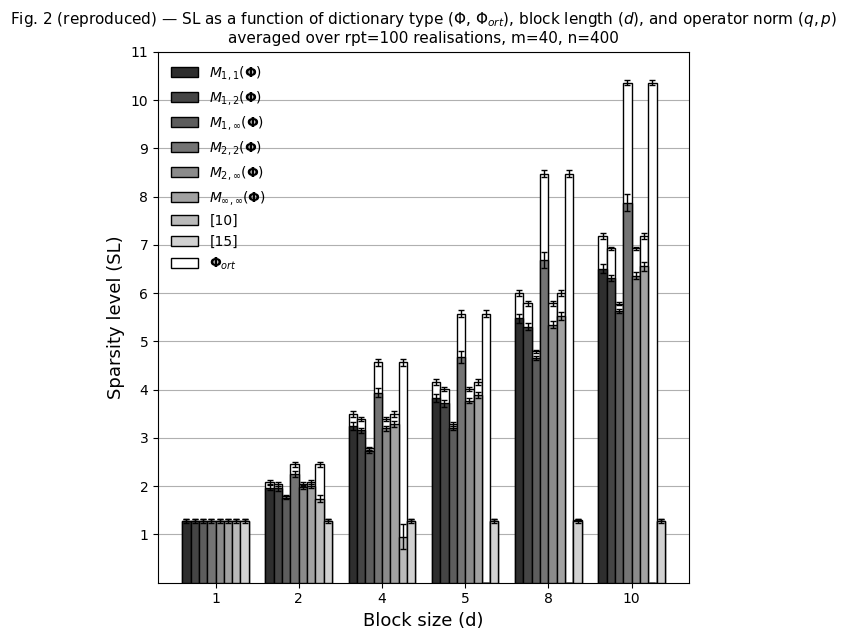

In [5]:
n_groups = nR
n_cats = 8
group_pos = np.arange(1, n_groups + 1)
total_width = 0.8
bar_width = total_width / n_cats
offsets = (np.arange(n_cats) - (n_cats - 1) / 2) * bar_width

# grayscale colormap, dark -> light
gray_full = plt.cm.gray(np.linspace(0, 1, n_cats + 4))
gray_colors = gray_full[2:-2]

fig, ax = plt.subplots(figsize=(9, 6.5))
handles = []
for c in range(n_cats):
    x = group_pos + offsets[c]
    # Phi_ort: white bars, drawn first (behind)
    ax.bar(x, tmpMeanOrth[:, c], width=bar_width, color='white',
           edgecolor='black', linewidth=1,
           yerr=tmpStdOrth[:, c], error_kw=dict(ecolor='black', elinewidth=1, capsize=2),
           zorder=2)
    # Phi: grayscale bars, drawn second (in front)
    h = ax.bar(x, tmpMean[:, c], width=bar_width, color=gray_colors[c],
               edgecolor='black', linewidth=1,
               yerr=tmpStd[:, c], error_kw=dict(ecolor='black', elinewidth=1, capsize=2),
               zorder=3)
    handles.append(h)

handles.append(mpatches.Patch(facecolor='white', edgecolor='black'))
labels = [r'$M_{1,1}(\mathbf{\Phi})$', r'$M_{1,2}(\mathbf{\Phi})$', r'$M_{1,\infty}(\mathbf{\Phi})$',
          r'$M_{2,2}(\mathbf{\Phi})$', r'$M_{2,\infty}(\mathbf{\Phi})$', r'$M_{\infty,\infty}(\mathbf{\Phi})$',
          EldarRef, DonohoRef, r'$\mathbf{\Phi}_{ort}$']

ax.set_xticks(group_pos)
ax.set_xticklabels([str(v) for v in r_list])
ax.set_xlabel('Block size (d)', fontsize=13)
ax.set_ylabel('Sparsity level (SL)', fontsize=13)
ax.set_ylim(0, 11)
ax.set_yticks(range(1, 12))
ax.grid(True, axis='y', zorder=0)
ax.set_axisbelow(True)
ax.set_box_aspect(1)
ax.legend(handles, labels, loc='upper left', frameon=False, fontsize=10)
ax.set_title('Fig. 2 (reproduced) — SL as a function of dictionary type (${\Phi}$, ${\Phi}_{ort}$), block length ($d$), and operator norm $(q,p)$\n'
             f'averaged over rpt={rpt} realisations, m={m}, n={n}', fontsize=11)
plt.tight_layout()
plt.savefig('fig2_reproduced.pdf', bbox_inches='tight')
plt.savefig('fig2_reproduced.png', dpi=300, bbox_inches='tight')
plt.show()

## Experiment II (Fig. 3): SL vs. [11]'s sub-coherence

This second experiment reuses the exact same `bmcc_coeff` / `bmcc` functions defined in Experiment I to compare, as a function of the dictionary's **sub-coherence**, the sparsity level (SL) guaranteed by:

* the 6 proposed $M_{q,p}(\mathbf{\Phi})$ conditions (all six tractable operator-norm pairs), and
* [11]'s block-coherence condition (Theorem 3 of [11]).

[11] define the **sub-coherence** $\nu$ of a dictionary $\mathbf{D}$ as (Eq. 8 of [11])
$$\nu = \max_{\ell}\max_{i,j\neq i}\left|\mathbf{d}_i^H\mathbf{d}_j\right|,\quad \mathbf{d}_i,\mathbf{d}_j\in\mathbf{D}[\ell],$$
i.e. the largest absolute inner product between two *different* columns of the *same* block — exactly the quantity returned in `bmcc()[7]`. Their recovery condition (Eq. 41) is
$$kd < \frac{1}{2}\left(\mu_B^{-1} + d - \frac{(d-1)\nu}{\mu_B}\right),$$
which is the block-coherence $\mu_B$ bound *penalised* by a term growing linearly in $\nu$ and in $(d-1)$: the more correlated the columns are within a block, the harder [11]'s guarantee is hit, and this penalty compounds for larger blocks. The proposed $M_{q,p}(\mathbf{\Phi})$-based bound (Theorem III.3) carries no such explicit $\nu$-penalty term, because it is built from the Moore–Penrose pseudo-inverse of each block, which internally "deskews" intra-block correlations.

**Parameters**: $m=40$, $n=400$, block sizes $d\in\{2,4,5,8,10\}$, sub-coherence targets $\nu\in\{0.00,0.05,...,0.50\}$, `rpt=100` random dictionaries per $(d,\nu)$ pair (for mean/std).

In [6]:
def subcoherence_dictionary(m, n, d, nu, rng):
    """Random (m, n) dictionary partitioned into n/d blocks of length d such that
    every pair of different columns within the same block has inner product
    exactly `nu` in absolute value ([11]'s sub-coherence, Eq. 8), while the
    between-block structure is left free/random.

    Column i of block k is  sqrt(nu) * u_k + sqrt(1 - nu) * q_{k,i}, where u_k is a
    random unit vector and {q_{k,i}}_i is an orthonormal basis of a random
    d-dimensional subspace of the orthogonal complement of u_k. Requires d <= m-1.
    """
    blocks_nb = n // d
    U = rng.standard_normal((blocks_nb, m))
    U = U / np.linalg.norm(U, axis=1, keepdims=True)                 # (blocks_nb, m), the u_k's

    V = rng.standard_normal((blocks_nb, m, d))
    proj = np.einsum('bm,bmd->bd', U, V)                             # u_k^T v_{k,i}
    V = V - np.einsum('bm,bd->bmd', U, proj)                         # project out the u_k component
    Q, _ = np.linalg.qr(V)                                           # (blocks_nb, m, d), orthonormal & ⊥ u_k

    blocks = np.sqrt(nu) * U[:, :, None] + np.sqrt(1 - nu) * Q       # (blocks_nb, m, d)
    phi = blocks.transpose(1, 0, 2).reshape(m, n)
    return phi

In [7]:
d_list = [2, 4, 5, 8, 10]                                  # block sizes for this experiment
nu_list = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]       # sub-coherence sweep
rpt_nu = 100                                                # repetitions per (d, nu) pair

nD, nNu = len(d_list), len(nu_list)
rng_nu = np.random.default_rng(seed)

# BMCC_sub[repetition, coherence-constant(9), block-size, sub-coherence]
BMCC_sub = np.full((rpt_nu, 9, nD, nNu), np.nan)

t0 = time.time()
for di, d in enumerate(d_list):
    for ni, nu in enumerate(nu_list):
        for i in range(rpt_nu):
            phi = subcoherence_dictionary(m, n, d, nu, rng_nu)
            BMCC_sub[i, :, di, ni] = bmcc(phi, d)
    print(f"  d={d} done — {time.time() - t0:.1f}s elapsed")

print(f"Simulation finished in {time.time() - t0:.1f}s")

# sanity check: the empirical sub-coherence (BMCC_sub[:,7]) should match nu_list almost exactly by construction
print("empirical nu (mean over reps, d=4):", np.nanmean(BMCC_sub[:, 7, d_list.index(4), :], axis=0))
print("target nu:                         ", nu_list)

  d=2 done — 200.9s elapsed
  d=4 done — 362.8s elapsed
  d=5 done — 508.9s elapsed
  d=8 done — 618.5s elapsed
  d=10 done — 715.6s elapsed
Simulation finished in 715.6s
empirical nu (mean over reps, d=4): [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
target nu:                          [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


### 1. SL computation

Same formulas as Section 3 (Theorem III.3 for the proposed conditions, Eq. 41 of [11] for [11]'s), evaluated at each $(d,\nu)$ point and averaged over the `rpt_nu` repetitions. Negative values are clipped to 0, as before.

In [8]:
# SL_sub_{mean,std}[method, block-size, sub-coherence]; method 0:6 = proposed M_qp, method 6 = [11]
SL_sub_mean = np.full((7, nD, nNu), np.nan)
SL_sub_std = np.full((7, nD, nNu), np.nan)

for di, d in enumerate(d_list):
    for ni in range(nNu):
        # Proposed BERC (Theorem III.3), all 6 (q,p) pairs
        M = BMCC_sub[:, 0:6, di, ni]
        SL_prop = d * (1 + (d * M) ** (-1)) / 2
        SL_prop[SL_prop < 0] = 0
        SL_sub_mean[0:6, di, ni] = SL_prop.mean(axis=0)
        SL_sub_std[0:6, di, ni] = SL_prop.std(axis=0)

        # [11]'s BERC
        mu_B = BMCC_sub[:, 6, di, ni]
        nu_emp = BMCC_sub[:, 7, di, ni]
        SL_eldar = d * (1 + (d * mu_B) ** (-1) - ((d - 1) * nu_emp) / (d * mu_B)) / 2
        SL_eldar[SL_eldar < 0] = 0
        SL_sub_mean[6, di, ni] = SL_eldar.mean()
        SL_sub_std[6, di, ni] = SL_eldar.std()

### 2. Plot — SL vs. sub-coherence, one panel per block size

One subplot per block size $d$. In every panel shaded bands show $\pm 1$ standard deviation across the `rpt_nu` repetitions.

<>:141: SyntaxWarning: invalid escape sequence '\P'
<>:186: SyntaxWarning: invalid escape sequence '\P'
<>:141: SyntaxWarning: invalid escape sequence '\P'
<>:186: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_2719/1068587631.py:141: SyntaxWarning: invalid escape sequence '\P'
  ax.set_xlabel(f'Sub-coherence $M^{{{EldarRef}}}_{{Intra}}(\Phi)$', fontsize=11)
/tmp/ipykernel_2719/1068587631.py:186: SyntaxWarning: invalid escape sequence '\P'
  f'SL as a function of sub-coherence $M^{{{EldarRef}}}_{{Intra}}(\Phi)$\n'


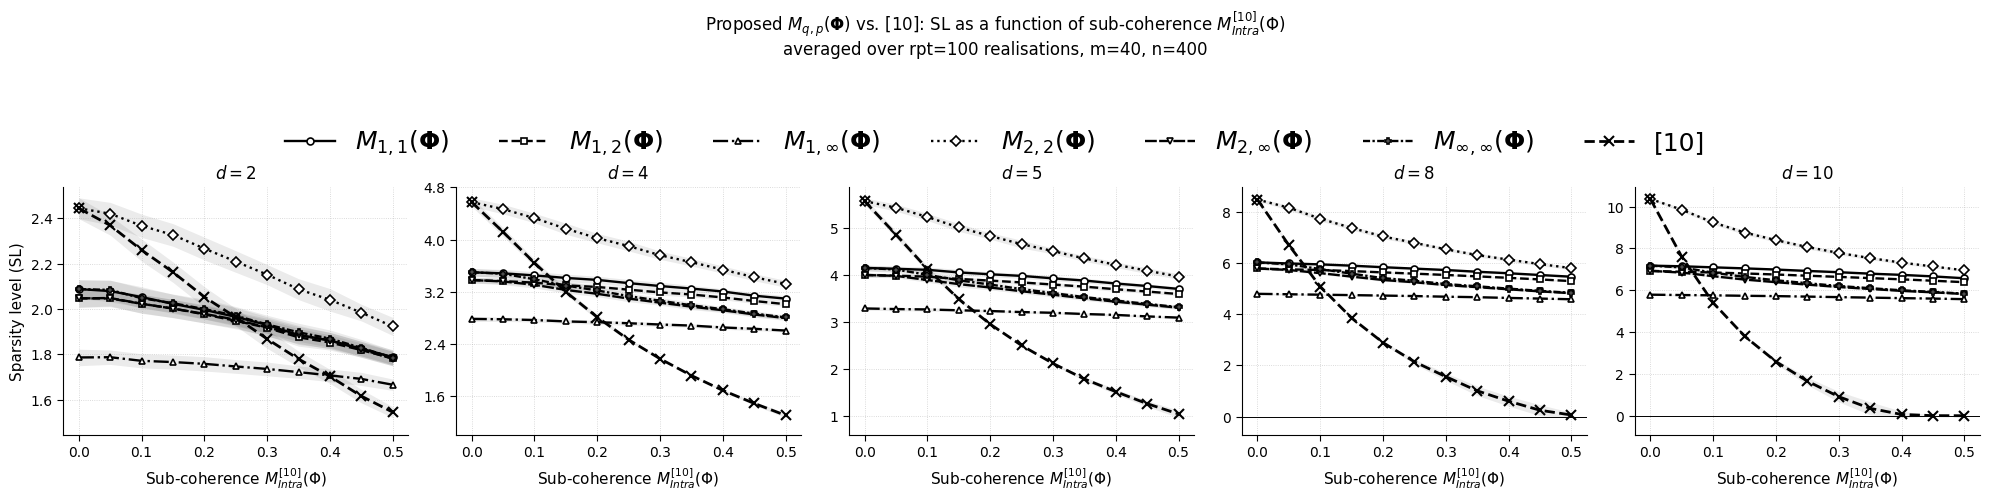

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


colors_qp = ['black'] * 6

markers_qp = ['o', 's', '^', 'D', 'v', 'P']

linestyles_qp = [
    '-',      # solid
    '--',     # dashed
    '-.',     # dash-dot
    ':',      # dotted
    (0, (5, 1)),       # custom dash
    (0, (3, 1, 1, 1)) # custom dash-dot
]

labels_qp = [
    r'$M_{1,1}(\mathbf{\Phi})$',
    r'$M_{1,2}(\mathbf{\Phi})$',
    r'$M_{1,\infty}(\mathbf{\Phi})$',
    r'$M_{2,2}(\mathbf{\Phi})$',
    r'$M_{2,\infty}(\mathbf{\Phi})$',
    r'$M_{\infty,\infty}(\mathbf{\Phi})$'
]

nu_arr = np.array(nu_list)

fig, axes = plt.subplots(
    1, nD,
    figsize=(4 * nD, 4.2)
)

if nD == 1:
    axes = [axes]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
for di, d in enumerate(d_list):

    ax = axes[di]

    # Proposed methods
    for c in range(6):

        mean = SL_sub_mean[c, di, :]
        std = SL_sub_std[c, di, :]

        ax.plot(
            nu_arr,
            mean,
            color='black',
            linestyle=linestyles_qp[c],
            marker=markers_qp[c],
            markersize=5,
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=1.2,
            linewidth=1.7,
            label=labels_qp[c]
        )

        # Use light grayscale / hatch-free uncertainty
        ax.fill_between(
            nu_arr,
            mean - std,
            mean + std,
            color='black',
            alpha=0.08,
            linewidth=0
        )

    # -----------------------------------------------------
    # [11]
    # -----------------------------------------------------
    mean_e = SL_sub_mean[6, di, :]
    std_e = SL_sub_std[6, di, :]

    ax.plot(
        nu_arr,
        mean_e,
        color='black',
        linestyle='--',
        marker='x',
        markersize=7,
        markeredgewidth=1.5,
        linewidth=2.0,
        label=EldarRef
    )

    ax.fill_between(
        nu_arr,
        mean_e - std_e,
        mean_e + std_e,
        color='black',
        alpha=0.08,
        linewidth=0
    )

    # -----------------------------------------------------
    # Dynamic y-axis
    # -----------------------------------------------------
    y_values = []

    for c in range(7):
        mean = SL_sub_mean[c, di, :]
        std = SL_sub_std[c, di, :]

        y_values.extend(mean - std)
        y_values.extend(mean + std)

    y_values = np.asarray(y_values)
    y_values = y_values[np.isfinite(y_values)]

    y_min = np.min(y_values)
    y_max = np.max(y_values)

    y_range = y_max - y_min
    margin = 0.08 * y_range if y_range > 0 else 0.05

    # Only set the lower bound; let matplotlib determine upper bound
    ax.set_ylim(bottom=y_min - margin)

    # -----------------------------------------------------
    # Ticks and labels
    # -----------------------------------------------------
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=10,
        direction='out',
        length=4,
        width=0.8
    )

    ax.set_title(f'$d = {d}$', fontsize=12)
    ax.set_xlabel(f'Sub-coherence $M^{{{EldarRef}}}_{{Intra}}(\Phi)$', fontsize=11)

    if di == 0:
        ax.set_ylabel('Sparsity level (SL)', fontsize=11)

    # -----------------------------------------------------
    # Grid
    # -----------------------------------------------------
    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.6,
        alpha=0.6
    )

    # Zero line
    ax.axhline(
        0,
        color='black',
        linestyle='-',
        linewidth=0.7
    )

    # Clean axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------
handles, lbls = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    lbls,
    loc='upper center',
    ncol=7,
    frameon=False,
    bbox_to_anchor=(0.5, 0.95),
    fontsize=18
)

fig.suptitle(
    f'Proposed $M_{{q,p}}(\\mathbf{{\\Phi}})$ vs. {EldarRef}: '
    f'SL as a function of sub-coherence $M^{{{EldarRef}}}_{{Intra}}(\Phi)$\n'
    f'averaged over rpt={rpt_nu} realisations, m={m}, n={n}',
    y=1.18,
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    'sl_vs_subcoherence.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'sl_vs_subcoherence.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()